
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

**1. Planteamiento del problema**

Queremos resolver la EDO de segundo orden con condiciones de frontera de Dirichlet:

$$-\frac{d^2y}{dx^2} = f(x), x \in [a,b]$$
$$y(a)=y_a, y(b)=y_b$$

En nuestro caso $f(x)=xe^x$, $[a,b]=[0,1]$, $y_a=3-e$, $y_b=0$. 

Para hacerlo general, el código resuelve la forma

$$-\frac{d}{dx}\left(p(x)\frac{dy}{dx}\right) + q(x)y = f(x)$$

que se reduce a nuestro problema con $p=1$, $q=0$.

**2. Forma débil**

La idea del FEM es no exigir que la ecuación se cumpla punto a punto, sino "en promedio". Se multiplica la ecuación por una función de prueba $v(x)$ con $v(a)=v(b)=0$ y se integra:

$$\int_a^b -(py')'v dx + \int_a^b qyv dx = \int_a^b fv dx$$

Integrando por partes el primer término, el término de frontera $[-py'v]_a^b$ se anula porque $v(a)=v(b)=0$:

$$\int_a^b(py'v' + qyv) dx= \int_a^b fv dx$$

Esto baja el orden de derivación, y por eso se pueden usar funciones lineales por tramos.


**3. Discretización**

Se divide $[a,b]$ en $N$ elementos con nodos $x_0 = a<x_1<...<x_N =b$. Se aproxima 

$$y(x) \approx y_h(x) = \sum_{j=0}^N y_j \varphi_j(x)$$

donde $\varphi_j$ son las funciones "sombrero" (lineales por tramos) con $\varphi_j(x_i)=\delta_{ij}$. Asi, $y_j$ es directamente el valor de la solución en el nodo $x_j$. 

En un elemento $[x_e, x_{e+1}]$ de longitud $h_e$ solo son no nulas dos funciones:

\begin{align*}
    N_1(x)=\frac{x_{e+1}-x}{h_e},  &&  N_2(x)=\frac{x-x_{e}}{h_e}
\end{align*}


**4. Sistema lineal (método de Galerkin)**

Se toma como función de prueba $v=\varphi_i$ para cada $i$ (las mismas funciones que se usan para aproximar la solución). Al sustituir $y_h=\sum_j y_j\varphi_j$ en la forma débil se obtiene el sistema lineal

$$K\,\mathbf{y}=\mathbf{F}$$

con

$$K_{ij}=\int_a^b\left(p\,\varphi_i'\,\varphi_j'+q\,\varphi_i\,\varphi_j\right)dx,\qquad F_i=\int_a^b f\,\varphi_i\,dx$$

Como cada $\varphi_i$ solo se solapa con sus vecinas inmediatas, $K_{ij}=0$ si $|i-j|>1$, por lo que $K$ es una matriz **tridiagonal**.

**Matrices locales.** Las integrales se calculan elemento por elemento. Para el elemento $[x_e,x_{e+1}]$ de longitud $h_e$, con $p$ y $q$ constantes:

$$K^{(e)}=\frac{p}{h_e}\begin{pmatrix}1&-1\\-1&1\end{pmatrix}+\frac{q\,h_e}{6}\begin{pmatrix}2&1\\1&2\end{pmatrix},\qquad F^{(e)}_i=\int_{x_e}^{x_{e+1}} f(x)\,N_i(x)\,dx,\quad i=1,2$$

En el código, estas integrales se evalúan con cuadratura de Gauss-Legendre, de modo que el método funciona para cualquier $p$, $q$ y $f$.

**Ensamblaje.** Las contribuciones locales se suman en la matriz global en las posiciones de los nodos que comparte cada elemento: $K^{(e)}$ se acumula en las filas y columnas $(e,\,e+1)$ de $K$, y $F^{(e)}$ en las posiciones $(e,\,e+1)$ de $\mathbf{F}$.

**5. Condiciones de Dirichlet**

Los valores en los extremos son conocidos: $y_0=y_a$ y $y_N=y_b$. Por lo tanto, solo hay que resolver para los nodos interiores $i=1,\dots,N-1$. Los términos que involucran a $y_0$ y $y_N$ se pasan al lado derecho:

$$\sum_{j=1}^{N-1}K_{ij}\,y_j=F_i-K_{i0}\,y_a-K_{iN}\,y_b,\qquad i=1,\dots,N-1$$

Esto equivale a eliminar la primera y la última fila y columna de $K$, y corregir el vector $\mathbf{F}$ con las condiciones de frontera. El sistema resultante, de tamaño $(N-1)\times(N-1)$, es tridiagonal y se resuelve directamente. Finalmente, la solución completa es $\mathbf{y}=(y_a,\,y_1,\dots,y_{N-1},\,y_b)$.

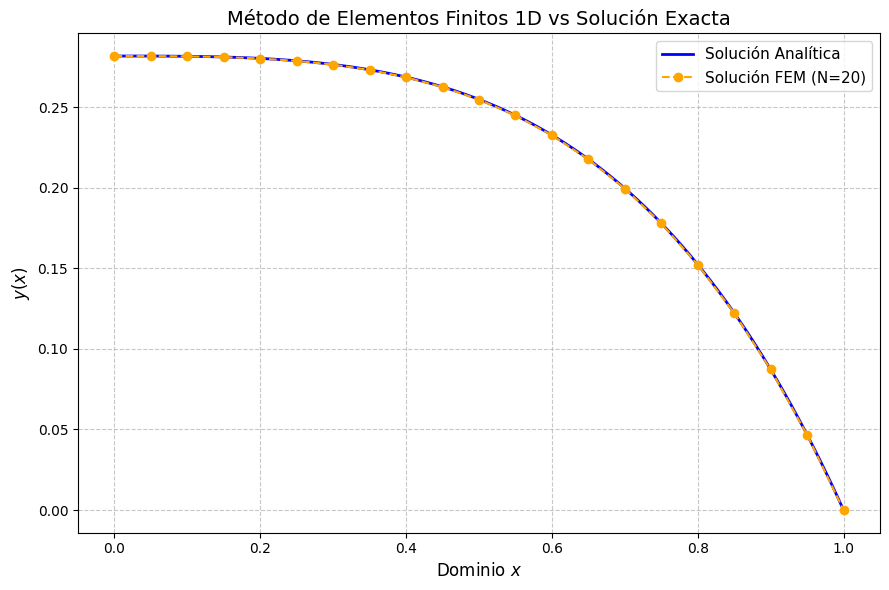

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def solve_fem_1d(a, b, N, f, ya, yb):
    # Generar la malla
    x = np.linspace(a, b, N + 1) #define los nodos espaciales
    h = (b - a) / N  #calcula la longitud uniforme de cada elemento espacial
    
    # Inicializar matriz global A y vector de carga B
    A = np.zeros((N + 1, N + 1))
    B = np.zeros(N + 1)
    
    # Matriz de rigidez local estándar para elementos lineales 1D
    K_local = (1/h) * np.array([[1, -1], [-1, 1]])
    
    # Ensamblaje de la matriz A y el vector B
    for i in range(N):
        # Ensamblar matriz de rigidez
        A[i:i+2, i:i+2] += K_local
        
        # Ensamblar vector de carga (usando aproximación del trapecio para la integral)
        # B_i = integral( f(x)*phi_i(x) ) dx
        B[i] += f(x[i]) * h / 2
        B[i+1] += f(x[i+1]) * h / 2

    # Aplicar condiciones de frontera de Dirichlet
    # Modificar el nodo izquierdo (x = a)
    A[0, :] = 0
    A[0, 0] = 1
    B[0] = ya
    
    # Modificar el nodo derecho (x = b)
    A[-1, :] = 0
    A[-1, -1] = 1
    B[-1] = yb
    
    # Resolver el sistema lineal A * y = B
    y = np.linalg.solve(A, B)
    
    return x, y

# Para este ejercicio en particular
a, b = 0, 1
ya = 3 - np.e
yb = 0
N_elements = 20 

def source_function(x):
    return x * np.exp(x)

def analytical_solution(x):
    return 1 - np.e - np.exp(x)*(x - 2) - x

# Ejecutar FEM
x_fem, y_fem = solve_fem_1d(a, b, N_elements, source_function, ya, yb)

# Calcular solución analítica para comparar
x_exact = np.linspace(a, b, 100)
y_exact = analytical_solution(x_exact)

# Grafica
plt.figure(figsize=(9, 6))
plt.plot(x_exact, y_exact, label='Solución Analítica', color='blue', linewidth=2)
plt.plot(x_fem, y_fem, 'o--', label=f'Solución FEM (N={N_elements})', color='orange', markersize=6)
plt.title("Método de Elementos Finitos 1D vs Solución Exacta", fontsize=14)
plt.xlabel("Dominio $x$", fontsize=12)
plt.ylabel("$y(x)$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()